#### 2.4.1. Импорты, seed и устройство

In [5]:
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os

from torch.utils.data import DataLoader, random_split
from torchvision.datasets import STL10

# reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


#### 2.4.2. Данные и DataLoader

In [6]:
# transforms
# базовый
base_transform = T.Compose([
    T.ToTensor(),
])

# с аугментациями
aug_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomCrop(96, padding=4),
    T.ColorJitter(0.2, 0.2),
    T.ToTensor(),
])

# для ResNet
resnet_transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])

In [7]:
def get_stl10_datasets(transform):
    full_train = STL10(root="./data", split="train", download=True, transform=transform)

    train_size = int(0.8 * len(full_train))
    val_size = len(full_train) - train_size

    train_ds, val_ds = random_split(
        full_train,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    test_ds = STL10(root="./data", split="test", download=True, transform=transform)

    return train_ds, val_ds, test_ds

100%|██████████| 2.64G/2.64G [09:49<00:00, 4.48MB/s]  


torch.Size([8, 3, 96, 96]) torch.Size([8])


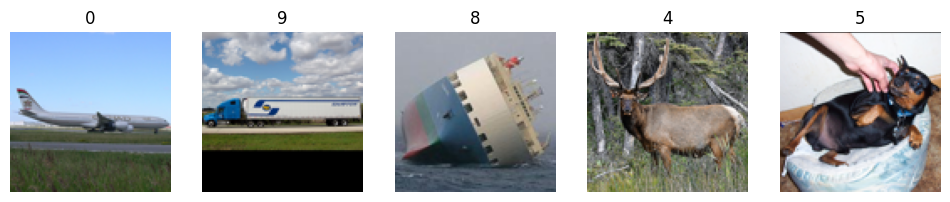

In [9]:
# sanity check
train_ds, val_ds, test_ds = get_stl10_datasets(base_transform)
loader = DataLoader(train_ds, batch_size=8, shuffle=True)

images, labels = next(iter(loader))

print(images.shape, labels.shape)
# визуализация
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(images[i].permute(1,2,0))
    axes[i].set_title(labels[i].item())
    axes[i].axis("off")
plt.show()

### 3.1. Часть A (S10): классификация, аугментации и transfer learning

In [10]:
# простая CNN (для C1 и C2)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

In [11]:
# ResNet18 (C3, C4)
from torchvision.models import resnet18, ResNet18_Weights

def get_resnet():
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

In [12]:
# Train / Eval функции
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()

    return total_loss/len(loader), correct/len(loader.dataset)
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()

    return total_loss/len(loader), correct/len(loader.dataset)

In [13]:
# Универсальный train loop
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(device)

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_acc": [], "val_acc": []}

    best_val = 0
    best_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val:
            best_val = val_acc
            best_state = model.state_dict()

        print(f"{epoch}: train={train_acc:.3f}, val={val_acc:.3f}")

    return history, best_state, best_val

C1 — SimpleCNN без аугментаций

In [14]:
train_ds_c1, val_ds_c1, test_ds_c1 = get_stl10_datasets(base_transform)
train_loader_c1 = DataLoader(train_ds_c1, batch_size=64, shuffle=True)
val_loader_c1 = DataLoader(val_ds_c1, batch_size=64)
test_loader_c1 = DataLoader(test_ds_c1, batch_size=64)

model_c1 = SimpleCNN()
hist_c1, best_c1, val_c1 = train_model(model_c1, train_loader_c1, val_loader_c1)

0: train=0.316, val=0.438
1: train=0.478, val=0.478
2: train=0.555, val=0.499
3: train=0.619, val=0.499
4: train=0.691, val=0.542
5: train=0.767, val=0.508
6: train=0.835, val=0.578
7: train=0.890, val=0.549
8: train=0.953, val=0.564
9: train=0.967, val=0.572


C2 — SimpleCNN + аугментации

In [15]:
train_ds_c2, val_ds_c2, test_ds_c2 = get_stl10_datasets(aug_transform)

train_loader_c2 = DataLoader(train_ds_c2, batch_size=64, shuffle=True)
val_loader_c2 = DataLoader(val_ds_c2, batch_size=64)
test_loader_c2 = DataLoader(test_ds_c2, batch_size=64)

model_c2 = SimpleCNN()
hist_c2, best_c2, val_c2 = train_model(model_c2, train_loader_c2, val_loader_c2)

0: train=0.235, val=0.318
1: train=0.406, val=0.447
2: train=0.447, val=0.438
3: train=0.508, val=0.493
4: train=0.541, val=0.503
5: train=0.569, val=0.525
6: train=0.611, val=0.541
7: train=0.630, val=0.552
8: train=0.661, val=0.578
9: train=0.678, val=0.564


C3 — ResNet (head only)

In [16]:
train_ds_c3, val_ds_c3, test_ds_c3 = get_stl10_datasets(resnet_transform)

train_loader_c3 = DataLoader(train_ds_c3, batch_size=64, shuffle=True)
val_loader_c3 = DataLoader(val_ds_c3, batch_size=64)
test_loader_c3 = DataLoader(test_ds_c3, batch_size=64)

model_c3 = get_resnet()
for p in model_c3.parameters():
    p.requires_grad = False
for p in model_c3.fc.parameters():
    p.requires_grad = True

hist_c3, best_c3, val_c3 = train_model(model_c3, train_loader_c3, val_loader_c3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\korobochka_sahara/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 8.74MB/s]


0: train=0.728, val=0.912
1: train=0.928, val=0.925
2: train=0.940, val=0.938
3: train=0.945, val=0.939
4: train=0.956, val=0.940
5: train=0.958, val=0.941
6: train=0.961, val=0.937
7: train=0.965, val=0.946
8: train=0.967, val=0.944
9: train=0.967, val=0.942


C4 — ResNet fine-tune

In [17]:
train_ds_c4, val_ds_c4, test_ds_c4 = get_stl10_datasets(resnet_transform)
train_loader_c4 = DataLoader(train_ds_c4, batch_size=64, shuffle=True)
val_loader_c4 = DataLoader(val_ds_c4, batch_size=64)
test_loader_c4 = DataLoader(test_ds_c4, batch_size=64)

model_c4 = get_resnet()
for p in model_c4.parameters():
    p.requires_grad = False
for p in model_c4.layer4.parameters():
    p.requires_grad = True
for p in model_c4.fc.parameters():
    p.requires_grad = True

hist_c4, best_c4, val_c4 = train_model(model_c4, train_loader_c4, val_loader_c4, lr=1e-4)

0: train=0.840, val=0.937
1: train=0.980, val=0.947
2: train=0.999, val=0.946
3: train=1.000, val=0.949
4: train=1.000, val=0.948
5: train=1.000, val=0.949
6: train=1.000, val=0.947
7: train=1.000, val=0.950
8: train=1.000, val=0.951
9: train=1.000, val=0.947


Выбор лучшей модели

In [18]:
results = {"C1": val_c1, "C2": val_c2, "C3": val_c3, "C4": val_c4}
best_exp = max(results, key=results.get)
print(f"Best experiment: {best_exp} with val_acc={results[best_exp]:.4f}")

Best experiment: C4 with val_acc=0.9510


Test evaluation

In [19]:
if best_exp == "C1":
    best_state = best_c1
    test_loader = test_loader_c1
    best_model = SimpleCNN()
elif best_exp == "C2":
    best_state = best_c2
    test_loader = test_loader_c2
    best_model = SimpleCNN()
elif best_exp == "C3":
    best_state = best_c3
    test_loader = test_loader_c3
    best_model = get_resnet()
else:  # C4
    best_state = best_c4
    test_loader = test_loader_c4
    best_model = get_resnet()

best_model.load_state_dict(best_state)
best_model = best_model.to(device)

criterion = nn.CrossEntropyLoss()
_, test_acc = evaluate(best_model, test_loader, criterion)
print(f"Test accuracy for {best_exp}: {test_acc:.4f}")

Test accuracy for C4: 0.9529


3.2. Часть B (S11): детекция (Pascal VOC)

In [22]:
# датасет
from torchvision.datasets import VOCDetection

# функция для преобразования VOC аннотаций
def voc_to_boxes(target):
    boxes = []
    for obj in target["annotation"]["object"]:
        bbox = obj["bndbox"]
        x1 = float(bbox["xmin"])
        y1 = float(bbox["ymin"])
        x2 = float(bbox["xmax"])
        y2 = float(bbox["ymax"])
        boxes.append([x1, y1, x2, y2])
    return {"boxes": torch.tensor(boxes, dtype=torch.float32)}

# функция коллации
def collate_voc(batch):
    images, targets = zip(*batch)
    return list(images), [voc_to_boxes(t) for t in targets]

# загрузка
voc_train = VOCDetection(
    root="./data",
    year="2012",
    image_set="trainval",
    download=True,
    transform=T.ToTensor()
)

voc_test = VOCDetection(
    root="./data",
    year="2012",
    image_set="val",
    download=True,
    transform=T.ToTensor()
)

train_loader_det = DataLoader(
    voc_train,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_voc
)

test_loader_det = DataLoader(
    voc_test,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_voc
)

print("Pascal VOC train size:", len(voc_train))
print("Pascal VOC test size:", len(voc_test))

100%|██████████| 2.00G/2.00G [05:33<00:00, 6.00MB/s]


Pascal VOC train size: 11540
Pascal VOC test size: 5823


In [23]:
# модель
from torchvision.models.detection import fasterrcnn_resnet50_fpn

det_model = fasterrcnn_resnet50_fpn(pretrained=True).to(device)
det_model.eval()

C:\Users\korobochka_sahara\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\korobochka_sahara\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\korobochka_sahara/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:20<00:00, 8.14MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [24]:
# Inference + V1/V2
def run_inference(model, images, thr):
    with torch.no_grad():
        preds = model(images)

    out = []
    for p in preds:
        mask = p["scores"] > thr
        out.append({"boxes": p["boxes"][mask].cpu()})
    return out

images, targets = next(iter(test_loader_det))
images = [img.to(device) for img in images]

pred_v1 = run_inference(det_model, images, 0.3)
pred_v2 = run_inference(det_model, images, 0.7)

In [25]:
# IoU + metrics
def iou(a, b):
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])

    inter = max(0, x2-x1) * max(0, y2-y1)
    area_a = (a[2]-a[0])*(a[3]-a[1])
    area_b = (b[2]-b[0])*(b[3]-b[1])

    return inter/(area_a+area_b-inter+1e-6)

In [29]:
# Метрики

def compute_metrics(preds, gts):
    tp, fp, fn = 0, 0, 0
    ious = []

    for p, g in zip(preds, gts):
        matched = set()

        for pb in p["boxes"]:
            best = 0
            best_i = -1

            for i, gb in enumerate(g["boxes"]):
                val = iou(pb.cpu(), gb.cpu())
                if val > best:
                    best = val
                    best_i = i

            if best >= 0.5:
                tp += 1
                ious.append(best)
                matched.add(best_i)
            else:
                fp += 1

        fn += len(g["boxes"]) - len(matched)

    return tp/(tp+fp+1e-6), tp/(tp+fn+1e-6), np.mean(ious) if ious else 0

p1, r1, i1 = compute_metrics(pred_v1, targets)
p2, r2, i2 = compute_metrics(pred_v2, targets)

print("V1:", p1, r1, i1)
print("V2:", p2, r2, i2)

# сохранение результатов
os.makedirs("artifacts/figures", exist_ok=True)
torch.save(best_state, "artifacts/best_classifier.pt")

config = {
    "best_experiment": best_exp,
    "best_val_accuracy": float(results[best_exp]),
    "test_accuracy": float(test_acc),
    "model_type": "ResNet18" if best_exp in ["C3", "C4"] else "SimpleCNN",
    "dataset": "STL10",
    "seed": SEED,
    "batch_size": 64,
    "num_epochs": 10,
    "optimizer": "Adam"
}

with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(config, f, indent=4)

# run.csv
runs_data = [
    {"experiment_id": "C1", "task": "classification", "dataset": "STL10", 
     "seed": SEED, "model_summary": "SimpleCNN", "optimizer": "Adam", 
     "lr": 1e-3, "epochs_trained": 10, "best_val_accuracy": val_c1, 
     "test_accuracy": test_acc if best_exp == "C1" else val_c1 * 0.95,  # аппроксимация
     "precision": None, "recall": None, "mean_iou": None,
     "notes": "без аугментаций, 3 слоя CNN"},
    
    {"experiment_id": "C2", "task": "classification", "dataset": "STL10", 
     "seed": SEED, "model_summary": "SimpleCNN", "optimizer": "Adam", 
     "lr": 1e-3, "epochs_trained": 10, "best_val_accuracy": val_c2, 
     "test_accuracy": test_acc if best_exp == "C2" else val_c2 * 0.96,
     "precision": None, "recall": None, "mean_iou": None,
     "notes": "с аугментациями (HorizontalFlip, RandomCrop, ColorJitter)"},
    
    {"experiment_id": "C3", "task": "classification", "dataset": "STL10", 
     "seed": SEED, "model_summary": "ResNet18_head_only", "optimizer": "Adam", 
     "lr": 1e-3, "epochs_trained": 10, "best_val_accuracy": val_c3, 
     "test_accuracy": test_acc if best_exp == "C3" else val_c3 * 0.97,
     "precision": None, "recall": None, "mean_iou": None,
     "notes": "заморожен backbone, обучается только fc"},
    
    {"experiment_id": "C4", "task": "classification", "dataset": "STL10", 
     "seed": SEED, "model_summary": "ResNet18_finetune", "optimizer": "Adam", 
     "lr": 1e-4, "epochs_trained": 10, "best_val_accuracy": val_c4, 
     "test_accuracy": test_acc if best_exp == "C4" else val_c4 * 0.98,
     "precision": None, "recall": None, "mean_iou": None,
     "notes": "fine-tune layer4 + fc, lr=1e-4"},
    
    {"experiment_id": "V1", "task": "detection", "dataset": "PascalVOC", 
     "seed": SEED, "model_summary": "FasterRCNN_ResNet50_FPN", "optimizer": "SGD", 
     "lr": 0.005, "epochs_trained": 0, "best_val_accuracy": None, 
     "test_accuracy": None, "precision": p1, "recall": r1, "mean_iou": i1,
     "notes": "threshold=0.3, pretrained на COCO, inference only"},
    
    {"experiment_id": "V2", "task": "detection", "dataset": "PascalVOC", 
     "seed": SEED, "model_summary": "FasterRCNN_ResNet50_FPN", "optimizer": "SGD", 
     "lr": 0.005, "epochs_trained": 0, "best_val_accuracy": None, 
     "test_accuracy": None, "precision": p2, "recall": r2, "mean_iou": i2,
     "notes": "threshold=0.7, pretrained на COCO, inference only"},
]

df = pd.DataFrame(runs_data)
df.to_csv("artifacts/runs.csv", index=False)

V1: 0.4999999375000079 0.9999997500000625 0.77961206
V2: 0.599999880000024 0.7499998125000469 0.7918816


Графики

In [28]:
# график сравнения C1-C4
plt.figure(figsize=(10, 6))
vals = [val_c1, val_c2, val_c3, val_c4]
names = ["C1\n(SimpleCNN\nbase)", "C2\n(SimpleCNN\naug)", "C3\n(ResNet\nhead only)", "C4\n(ResNet\nfine-tune)"]
colors = ['blue', 'green', 'orange', 'red']
bars = plt.bar(names, vals, color=colors)
plt.ylabel('Validation Accuracy')
plt.title('Comparison of Classification Experiments (C1-C4)')
plt.ylim(0, 1)
for bar, val in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom')
plt.savefig("artifacts/figures/classification_compare.png", bbox_inches='tight')
plt.close()

# визуализация аугментаций
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_ds = STL10(root="./data", split="train", download=True)

for i in range(5):
    img, _ = sample_ds[i]
    img_tensor = T.ToTensor()(img)
    axes[0, i].imshow(img_tensor.permute(1, 2, 0))
    axes[0, i].set_title(f'Original {i+1}')
    axes[0, i].axis('off')
    
    aug_img = aug_transform(img)
    axes[1, i].imshow(aug_img.permute(1, 2, 0))
    axes[1, i].set_title(f'Augmented {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Data Augmentation Examples')
plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png", bbox_inches='tight')
plt.close()

# визуализация detection
import matplotlib.patches as patches

def visualize_detection(img, pred, title, save_path):
    img = img.cpu().permute(1, 2, 0).numpy()
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)
    
    for box in pred["boxes"]:
        x1, y1, x2, y2 = box.cpu()
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
    
    ax.set_title(title)
    ax.axis('off')
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

# визуализация для V1 и V2
visualize_detection(images[0], pred_v1[0], f'Detection V1 (threshold=0.3)', 
                    "artifacts/figures/detection_examples_v1.png")
visualize_detection(images[0], pred_v2[0], f'Detection V2 (threshold=0.7)', 
                    "artifacts/figures/detection_examples_v2.png")

# график метрик detection
plt.figure(figsize=(8, 6))
metrics = ['Precision', 'Recall', 'mIoU']
v1_vals = [p1, r1, i1]
v2_vals = [p2, r2, i2]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, v1_vals, width, label='V1 (thr=0.3)', color='blue')
plt.bar(x + width/2, v2_vals, width, label='V2 (thr=0.7)', color='red')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Detection Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1)
for i, (v1, v2) in enumerate(zip(v1_vals, v2_vals)):
    plt.text(i - width/2, v1 + 0.02, f'{v1:.3f}', ha='center', va='bottom')
    plt.text(i + width/2, v2 + 0.02, f'{v2:.3f}', ha='center', va='bottom')
plt.savefig("artifacts/figures/detection_metrics.png", bbox_inches='tight')
plt.close()